# 04 — Explainability with SHAP

A probability on its own isn't actionable. A retention team needs to know *why* someone is flagged, and regulators require model decisions to be explainable.

**SHAP** (SHapley Additive exPlanations) assigns each feature a contribution to each individual prediction. Contributions sum to the gap between the model's average output and this particular prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import shap

from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("../figures"); FIG_DIR.mkdir(exist_ok=True)
SEED = 42

df = pd.read_parquet("../data/policyholders.parquet")

with open("../models/xgboost_model.pkl", "rb") as f:
    artefacts = pickle.load(f)

model = artefacts["model"]
threshold = artefacts["threshold"]
print(f"Model loaded. Decision threshold: {threshold}")

Model loaded. Decision threshold: 0.56


/opt/anaconda3/envs/lapsation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def engineer_features(data):
    d = data.copy()
    d["premium_to_sum_insured"] = d["annual_premium"] / d["sum_insured"] * 1000
    d["tenure_years"] = d["policy_tenure_months"] / 12
    return d.drop(columns=["policy_id", "policy_tenure_months"])

df_feat = engineer_features(df)
X, y = df_feat.drop(columns=["lapsed"]), df_feat["lapsed"]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)
print(f"Test set: {len(X_test):,} rows")

Test set: 15,000 rows


## 1. Compute SHAP values

SHAP runs on the transformed features the model actually sees, so the preprocessing step is applied first and the one-hot encoded names are recovered.

A 2,000-row sample keeps this fast; SHAP on the full set would take far longer for no extra insight.

In [3]:
sample = X_test.sample(2000, random_state=SEED)

prep = model.named_steps["prep"]
clf = model.named_steps["clf"]

X_trans = prep.transform(sample)
feature_names = [f.split("__", 1)[1] for f in prep.get_feature_names_out()]

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_trans)
print(f"SHAP values computed: {shap_values.shape}")

SHAP values computed: (2000, 13)


## 2. Global importance — what matters across all policyholders

The bar chart ranks features by mean absolute SHAP value: how much each one moves predictions on average, regardless of direction.

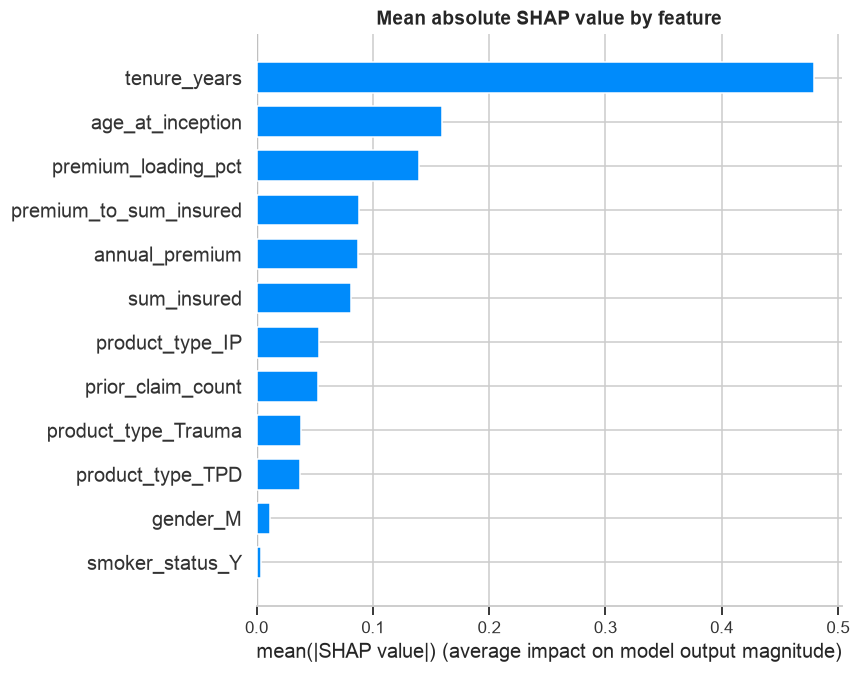

In [4]:
fig = plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_trans, feature_names=feature_names,
                  plot_type="bar", show=False, max_display=12)
plt.title("Mean absolute SHAP value by feature", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "17_shap_importance.png", bbox_inches="tight", dpi=150)
plt.show()

## 3. Beeswarm — direction as well as magnitude

Each dot is one policyholder. Position left or right shows whether that feature pushed their lapse risk down or up. Colour shows whether the feature value was high (red) or low (blue).

This is more informative than the bar chart: it shows *which direction* a high value pushes risk.

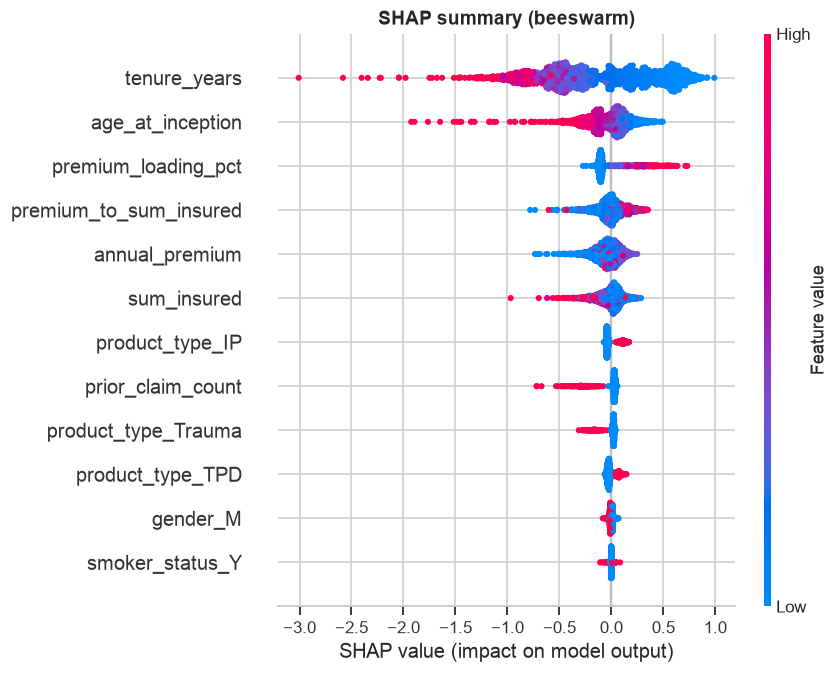

In [5]:
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_trans, feature_names=feature_names,
                  show=False, max_display=12)
plt.title("SHAP summary (beeswarm)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "18_shap_beeswarm.png", bbox_inches="tight", dpi=150)
plt.show()

**Reading this chart:** if `tenure_years` shows red dots on the left, that means high tenure pushes lapse risk *down* — long-standing policyholders are more loyal. That matches the EDA, which is a good consistency check.

## 4. Individual explanations

This is what a retention team would actually see: for one policyholder, which factors pushed their risk up and which pulled it down.

In [6]:
probas = model.predict_proba(sample)[:, 1]
high_idx = int(np.argmax(probas))
low_idx = int(np.argmin(probas))

print(f"Highest risk in sample: {probas[high_idx]:.1%}")
print(f"Lowest risk in sample:  {probas[low_idx]:.1%}")

Highest risk in sample: 81.9%
Lowest risk in sample:  2.2%


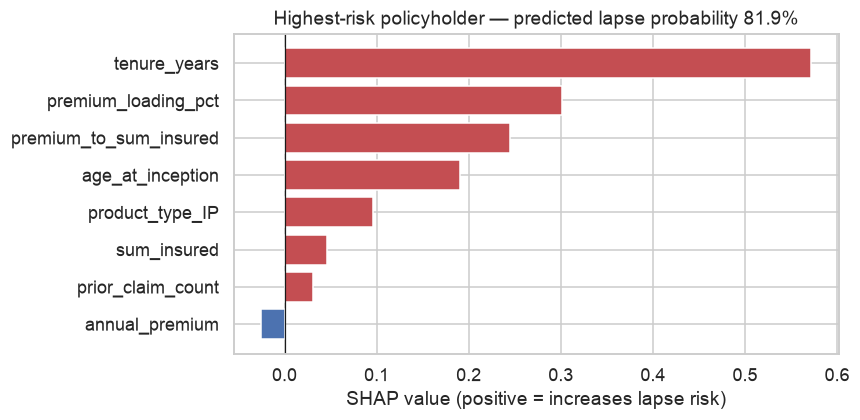


Highest-risk policyholder — policyholder details:
age_at_inception                   25
gender                              F
smoker_status                       N
product_type                       IP
sum_insured                     50000
annual_premium                 310.74
premium_loading_pct              32.9
prior_claim_count                 0.0
treaty_type               Quota Share
reinsurer                 Hannover Re
cession_pct                      40.0
ceded_premium                   124.3
ceded_sum_insured               20000
premium_to_sum_insured         6.2148
tenure_years                 0.166667


In [7]:
def explain_one(idx, label, filename):
    contrib = pd.DataFrame({
        "feature": feature_names,
        "shap": shap_values[idx],
    })
    contrib = contrib.reindex(contrib.shap.abs().sort_values(ascending=False).index).head(8)
    contrib = contrib.sort_values("shap")

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["#C44E52" if v > 0 else "#4C72B0" for v in contrib.shap]
    ax.barh(contrib.feature, contrib.shap, color=colors)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("SHAP value (positive = increases lapse risk)")
    ax.set_title(f"{label} — predicted lapse probability {probas[idx]:.1%}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, bbox_inches="tight", dpi=150)
    plt.show()

    print(f"\n{label} — policyholder details:")
    print(sample.iloc[idx].to_string())

explain_one(high_idx, "Highest-risk policyholder", "19_shap_high_risk.png")

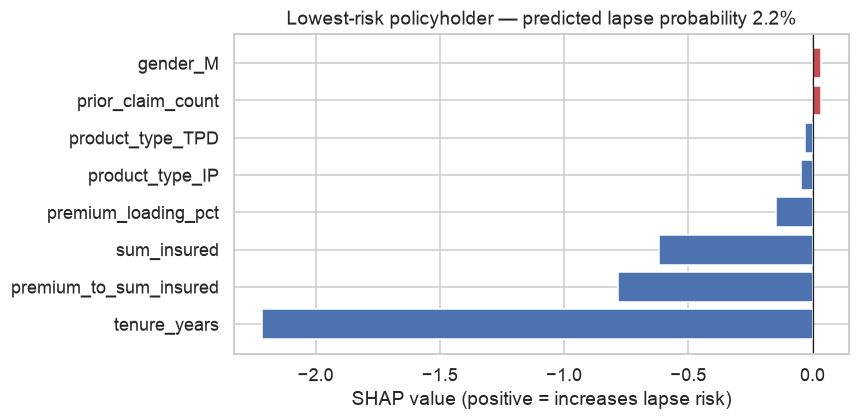


Lowest-risk policyholder — policyholder details:
age_at_inception                   22
gender                              F
smoker_status                       N
product_type                    Death
sum_insured                    771000
annual_premium                 797.79
premium_loading_pct               0.0
prior_claim_count                 0.0
treaty_type               Quota Share
reinsurer                 Hannover Re
cession_pct                      40.0
ceded_premium                  319.12
ceded_sum_insured              308400
premium_to_sum_insured       1.034747
tenure_years                19.333333


In [8]:
explain_one(low_idx, "Lowest-risk policyholder", "20_shap_low_risk.png")

## 5. Turning SHAP into a plain-English explanation

A chart is fine for an analyst. A retention team wants a sentence. This function converts SHAP output into readable text — exactly what the Streamlit app will display.

In [9]:
READABLE = {
    "tenure_years": "policy tenure",
    "premium_loading_pct": "underwriting loading",
    "age_at_inception": "age at inception",
    "prior_claim_count": "prior claims",
    "premium_to_sum_insured": "premium relative to cover",
    "annual_premium": "annual premium",
    "sum_insured": "sum insured",
    "product_type_IP": "income protection product",
    "product_type_TPD": "TPD product",
    "product_type_Trauma": "trauma product",
    "smoker_status_Y": "smoker status",
    "smoker_status_Unknown": "unknown smoker status",
    "gender_M": "gender",
}

def explain_in_words(idx, top_n=3):
    contrib = pd.DataFrame({"feature": feature_names, "shap": shap_values[idx]})
    contrib = contrib.reindex(contrib.shap.abs().sort_values(ascending=False).index).head(top_n)

    prob = probas[idx]
    band = "High" if prob >= threshold else ("Moderate" if prob >= threshold * 0.6 else "Low")

    raising = [READABLE.get(f, f) for f, s in zip(contrib.feature, contrib.shap) if s > 0]
    lowering = [READABLE.get(f, f) for f, s in zip(contrib.feature, contrib.shap) if s < 0]

    text = f"{band} lapse risk ({prob:.1%})."
    if raising:
        text += " Increasing risk: " + ", ".join(raising) + "."
    if lowering:
        text += " Reducing risk: " + ", ".join(lowering) + "."
    return text

print(explain_in_words(high_idx))
print()
print(explain_in_words(low_idx))

High lapse risk (81.9%). Increasing risk: policy tenure, underwriting loading, premium relative to cover.

Low lapse risk (2.2%). Reducing risk: policy tenure, premium relative to cover, sum insured.


## Summary

- SHAP gives both a global view (which features matter overall) and local explanations (why *this* policyholder was flagged)
- The directions agree with the EDA, which is a useful sanity check on the model
- SHAP output can be converted into plain English, which is what makes it usable by a non-technical retention team and auditable by a regulator

**Next:** `app.py` — a Streamlit app that puts this in front of a user.